# Modelos Mixtos — Combinaciones Conv1D, LSTM y GRU

Este notebook explora combinaciones de capas **convolucionales** (Conv1D) y **recurrentes** (LSTM, GRU) para la configuración fija:

- **Ventana de entrada:** 90 días
- **Ventana de salida:** 1 día

Arquitecturas evaluadas:
- `lstm` — LSTM apiladas
- `gru` — GRU apiladas
- `cnn_lstm` — Conv1D → LSTM
- `cnn_gru` — Conv1D → GRU

**Adaptación para input_w=90:** a diferencia del caso input_w=5 (donde `kernel_size=3` era fijo),
con 90 pasos temporales el tamaño del kernel Conv1D es un hiperparámetro relevante. Se añade
`kernel_size ∈ {3, 5, 7}` al grid de la Etapa 1 **solo para las variantes CNN**.

La búsqueda se realiza en dos etapas:
1. **Etapa 1 — Arquitectura**: tipo de red × n_layers × units × dropout (× kernel_size para CNN) — 96 combinaciones
2. **Etapa 2 — Entrenamiento**: learning rate × batch size con la mejor arquitectura de la Etapa 1 (9 combinaciones)

In [1]:
import sys
import itertools
import mlflow
from pathlib import Path

# Busca util.py subiendo niveles desde el directorio actual
_here = Path.cwd()
PROJECT_ROOT = next(
    p for p in [_here, _here.parent, _here.parent.parent, _here.parent.parent.parent]
    if (p / 'util.py').exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

mlflow.set_tracking_uri(f"sqlite:///{PROJECT_ROOT / 'model' / 'mlflow.db'}")

EXPERIMENT_NAME = "Modelos_Mixtos_input90_output1"
mlflow.set_experiment(EXPERIMENT_NAME)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import keras
from keras.models import Sequential
from keras.layers import LSTM, GRU, Dense, Input, Conv1D
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam

from sklearn.metrics import mean_absolute_error

from util import get_train_test, RANDOM_SEED, plot_training_curve

np.random.seed(RANDOM_SEED)
keras.utils.set_random_seed(RANDOM_SEED)

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/05/04 16:12:38 INFO mlflow.tracking.fluent: Experiment with name 'Modelos_Mixtos_input90_output1' does not exist. Creating a new experiment.


## Carga de datos

In [2]:
INPUT_W  = 90
OUTPUT_W = 1

def load_seq_data(input_window_size, output_window_size):
    d = get_train_test(input_window_size=input_window_size, output_window_size=output_window_size)
    X_train, X_test = d.X_train, d.X_test
    y_train, y_test = d.y_train, d.y_test
    val_size         = int(0.10 * X_train.shape[0])
    X_val, y_val     = X_train[-val_size:], y_train[-val_size:]
    X_train, y_train = X_train[:-val_size], y_train[:-val_size]
    return X_train, y_train, X_val, y_val, X_test, y_test

X_tr, y_tr, X_val, y_val, X_te, y_te = load_seq_data(INPUT_W, OUTPUT_W)

print(f"X_tr:  {X_tr.shape}   y_tr:  {y_tr.shape}")
print(f"X_val: {X_val.shape}  y_val: {y_val.shape}")
print(f"X_te:  {X_te.shape}   y_te:  {y_te.shape}")

X_tr:  (13037, 90, 23)   y_tr:  (13037, 23)
X_val: (1448, 90, 23)  y_val: (1448, 23)
X_te:  (1610, 90, 23)   y_te:  (1610, 23)


## Arquitecturas implementadas

La función `build_model` construye el modelo según el argumento `arch`:

| `arch`     | Capas                                      |
|------------|--------------------------------------------|
| `lstm`     | Input → LSTM × n_layers → Dense            |
| `gru`      | Input → GRU × n_layers → Dense             |
| `cnn_lstm` | Input → Conv1D → LSTM × n_layers → Dense   |
| `cnn_gru`  | Input → Conv1D → GRU × n_layers → Dense    |

Para las variantes CNN, `kernel_size` es ahora un hiperparámetro explorado en el grid
(valores: 3, 5, 7). Con 90 pasos de entrada, kernels más grandes capturan patrones de
frecuencia más baja (semanal ≈ 5, quincenal ≈ 7).

In [3]:
def build_model(arch, n_layers, units, dropout, kernel_size=5, lr=1e-3):
    keras.utils.set_random_seed(RANDOM_SEED)
    m = Sequential()
    m.add(Input(shape=(X_tr.shape[1], X_tr.shape[2])))

    if arch == "lstm":
        for i in range(n_layers):
            m.add(LSTM(units, return_sequences=(i < n_layers - 1), dropout=dropout))

    elif arch == "gru":
        for i in range(n_layers):
            m.add(GRU(units, return_sequences=(i < n_layers - 1), dropout=dropout))

    elif arch == "cnn_lstm":
        m.add(Conv1D(units, kernel_size=kernel_size, activation="relu", padding="same"))
        for i in range(n_layers):
            m.add(LSTM(units, return_sequences=(i < n_layers - 1), dropout=dropout))

    elif arch == "cnn_gru":
        m.add(Conv1D(units, kernel_size=kernel_size, activation="relu", padding="same"))
        for i in range(n_layers):
            m.add(GRU(units, return_sequences=(i < n_layers - 1), dropout=dropout))

    m.add(Dense(y_tr.shape[1]))
    m.compile(loss="mean_absolute_error", optimizer=Adam(learning_rate=lr))
    return m


def fit_eval(model, batch_size=128, epochs=200, patience=10, verbose=0):
    es = EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)
    h = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[es],
        verbose=verbose,
    )
    mae_tr  = mean_absolute_error(y_tr,  model.predict(X_tr,  verbose=0))
    mae_val = mean_absolute_error(y_val, model.predict(X_val, verbose=0))
    mae_te  = mean_absolute_error(y_te,  model.predict(X_te,  verbose=0))
    return mae_tr, mae_val, mae_te, h

## Etapa 1 — Búsqueda de arquitectura

Grid:
- **LSTM / GRU**: `arch` × `n_layers` × `units` × `dropout` → 24 combinaciones
- **CNN-LSTM / CNN-GRU**: `arch` × `n_layers` × `units` × `dropout` × `kernel_size` → 72 combinaciones

Total: **96 combinaciones**. Learning rate y batch size fijos en esta etapa.

Criterio de selección: **MAE de validación mínimo**.

In [4]:
pure_rnn_combos = [
    (arch, nl, u, dr, None)
    for arch, nl, u, dr in itertools.product(
        ["lstm", "gru"], [1, 2], [32, 64, 128], [0.0, 0.2]
    )
]
cnn_combos = [
    (arch, nl, u, dr, ks)
    for arch, nl, u, dr, ks in itertools.product(
        ["cnn_lstm", "cnn_gru"], [1, 2], [32, 64, 128], [0.0, 0.2], [3, 5, 7]
    )
]
arch_grid = pure_rnn_combos + cnn_combos
print(f"Total combinaciones Etapa 1: {len(arch_grid)}  (RNN puras: {len(pure_rnn_combos)}, CNN: {len(cnn_combos)})")

results_arch = []
batch_size_arch = 128

for arch, nl, u, dr, ks in arch_grid:
    ks_eff = ks if ks is not None else 0  # 0 = no aplica (RNN pura)
    run_name = (
        f"{EXPERIMENT_NAME}_arch_{arch}_layers{nl}_units{u}_drop{dr}"
        + (f"_ks{ks_eff}" if ks is not None else "")
    )
    existing = mlflow.search_runs(filter_string=f'tags.mlflow.runName = "{run_name}"')
    if not existing.empty:
        mlflow.delete_run(existing.iloc[0].run_id)

    with mlflow.start_run(run_name=run_name):
        model = build_model(arch, nl, u, dr, kernel_size=ks_eff if ks is not None else 5, lr=1e-3)
        mae_tr, mae_val, mae_te, h = fit_eval(model, batch_size=batch_size_arch)

        for epoch, (tl, vl) in enumerate(zip(h.history["loss"], h.history["val_loss"])):
            mlflow.log_metric("train_loss", tl, step=epoch)
            mlflow.log_metric("val_loss",   vl, step=epoch)

        fig = plot_training_curve(h)
        mlflow.log_figure(fig, "plots/loss_curve.png")
        plt.close(fig)

        mlflow.log_param("arch",               arch)
        mlflow.log_param("n_layers",           nl)
        mlflow.log_param("units",              u)
        mlflow.log_param("dropout",            dr)
        mlflow.log_param("kernel_size",        ks_eff)
        mlflow.log_param("learning_rate",      1e-3)
        mlflow.log_param("batch_size",         batch_size_arch)
        mlflow.log_param("input_window_size",  INPUT_W)
        mlflow.log_param("output_window_size", OUTPUT_W)
        mlflow.log_param("n_params",           model.count_params())
        mlflow.log_param("epochs",             len(h.history["loss"]))

        mlflow.log_metric("train_mae", mae_tr)
        mlflow.log_metric("val_mae",   mae_val)
        mlflow.log_metric("test_mae",  mae_te)

        mlflow.keras.log_model(model, name="model")

        results_arch.append({
            "arch": arch, "n_layers": nl, "units": u, "dropout": dr, "kernel_size": ks_eff,
            "MAE_train": mae_tr, "MAE_val": mae_val, "MAE_test": mae_te,
            "epochs": len(h.history["loss"]), "n_params": model.count_params(),
        })
        ks_str = f" ks={ks_eff}" if ks is not None else ""
        print(f"arch={arch:<10} layers={nl} units={u:>3} dropout={dr}{ks_str}  ->  val={mae_val:.6f} | train={mae_tr:.6f} | test={mae_te:.6f}")

results_arch_df = pd.DataFrame(results_arch).sort_values("MAE_val").reset_index(drop=True)

Total combinaciones Etapa 1: 96  (RNN puras: 24, CNN: 72)


2026/05/04 16:12:58 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


arch=lstm       layers=1 units= 32 dropout=0.0  ->  val=0.009106 | train=0.011863 | test=0.012300


2026/05/04 16:13:17 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


arch=lstm       layers=1 units= 32 dropout=0.2  ->  val=0.009095 | train=0.011859 | test=0.012291


...

arch=cnn_gru    layers=2 units=128 dropout=0.2 ks=3  ->  val=0.009082 | train=0.011820 | test=0.012276


2026/05/04 17:49:51 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


arch=cnn_gru    layers=2 units=128 dropout=0.2 ks=5  ->  val=0.009090 | train=0.011872 | test=0.012281


2026/05/04 17:51:28 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


arch=cnn_gru    layers=2 units=128 dropout=0.2 ks=7  ->  val=0.009097 | train=0.011908 | test=0.012286


### Resultados — Etapa 1 (top 10)

In [5]:
results_arch_df.head(10)

,arch,n_layers,units,dropout,kernel_size,MAE_train,MAE_val,MAE_test,epochs,n_params
0,cnn_lstm,1,32,0.2,5,0.011823,0.009054,0.012269,17,12791
1,cnn_lstm,2,32,0.2,5,0.011823,0.009056,0.012258,20,21111
2,cnn_lstm,2,32,0.0,3,0.011866,0.009058,0.012266,14,19639
3,cnn_gru,1,32,0.2,7,0.011770,0.009058,0.012246,19,12279
4,cnn_lstm,2,128,0.2,3,0.011828,0.009058,0.012263,17,275095
5,cnn_gru,2,32,0.2,5,0.011795,0.009059,0.012273,21,17143
6,cnn_lstm,2,32,0.2,3,0.011852,0.009060,0.012263,22,19639
7,cnn_gru,1,32,0.0,7,0.011722,0.009061,0.012245,18,12279
8,cnn_lstm,2,32,0.2,7,0.011855,0.009061,0.012269,15,22583
9,cnn_gru,2,32,0.2,7,0.011848,0.009062,0.012268,15,18615


## Etapa 2 — Hiperparámetros de entrenamiento

Se fija la arquitectura ganadora de la Etapa 1 y se busca sobre `learning_rate` × `batch_size`.

Criterio de selección: **MAE de validación mínimo**.

In [6]:
best_arch = results_arch_df.iloc[0]
best_ks   = int(best_arch.kernel_size)
print(f"Mejor arquitectura: arch={best_arch.arch}  n_layers={int(best_arch.n_layers)}  units={int(best_arch.units)}  dropout={best_arch.dropout}  kernel_size={best_ks}")
print(f"  MAE val = {best_arch.MAE_val:.6f}")

train_grid = list(itertools.product([1e-2, 1e-3, 1e-4], [64, 128, 256]))

results_train = []
for lr, bs in train_grid:
    run_name = f"{EXPERIMENT_NAME}_train_{best_arch.arch}_lr{lr:.0e}_batch{bs}"
    existing = mlflow.search_runs(filter_string=f'tags.mlflow.runName = "{run_name}"')
    if not existing.empty:
        mlflow.delete_run(existing.iloc[0].run_id)

    with mlflow.start_run(run_name=run_name):
        model = build_model(
            best_arch.arch, int(best_arch.n_layers), int(best_arch.units),
            float(best_arch.dropout), kernel_size=best_ks, lr=lr,
        )
        mae_tr, mae_val, mae_te, h = fit_eval(model, batch_size=bs)

        for epoch, (tl, vl) in enumerate(zip(h.history["loss"], h.history["val_loss"])):
            mlflow.log_metric("train_loss", tl, step=epoch)
            mlflow.log_metric("val_loss",   vl, step=epoch)

        fig = plot_training_curve(h)
        mlflow.log_figure(fig, "plots/loss_curve.png")
        plt.close(fig)

        mlflow.log_param("arch",               best_arch.arch)
        mlflow.log_param("n_layers",           int(best_arch.n_layers))
        mlflow.log_param("units",              int(best_arch.units))
        mlflow.log_param("dropout",            float(best_arch.dropout))
        mlflow.log_param("kernel_size",        best_ks)
        mlflow.log_param("learning_rate",      lr)
        mlflow.log_param("batch_size",         bs)
        mlflow.log_param("input_window_size",  INPUT_W)
        mlflow.log_param("output_window_size", OUTPUT_W)
        mlflow.log_param("n_params",           model.count_params())
        mlflow.log_param("epochs",             len(h.history["loss"]))

        mlflow.log_metric("train_mae", mae_tr)
        mlflow.log_metric("val_mae",   mae_val)
        mlflow.log_metric("test_mae",  mae_te)

        mlflow.keras.log_model(model, name="model")

        results_train.append({
            "learning_rate": lr, "batch_size": bs,
            "MAE_train": mae_tr, "MAE_val": mae_val, "MAE_test": mae_te,
            "epochs": len(h.history["loss"]),
        })
        print(f"lr={lr:.0e} batch={bs:>3}  ->  val={mae_val:.6f} | train={mae_tr:.6f} | test={mae_te:.6f}")

results_train_df = pd.DataFrame(results_train).sort_values("MAE_val").reset_index(drop=True)

Mejor arquitectura: arch=cnn_lstm  n_layers=1  units=32  dropout=0.2  kernel_size=5
  MAE val = 0.009054


2026/05/04 17:52:07 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


lr=1e-02 batch= 64  ->  val=0.009361 | train=0.012065 | test=0.012478


2026/05/04 17:52:25 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


lr=1e-02 batch=128  ->  val=0.009145 | train=0.011981 | test=0.012322


...

lr=1e-04 batch= 64  ->  val=0.009039 | train=0.011796 | test=0.012279


2026/05/04 17:56:31 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


lr=1e-04 batch=128  ->  val=0.009044 | train=0.011814 | test=0.012273


2026/05/04 17:57:41 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


lr=1e-04 batch=256  ->  val=0.009042 | train=0.011804 | test=0.012278


In [7]:
results_train_df

,learning_rate,batch_size,MAE_train,MAE_val,MAE_test,epochs
0,0.0001,64,0.011796,0.009039,0.012279,44
1,0.0001,256,0.011804,0.009042,0.012278,80
2,0.0010,256,0.011822,0.009043,0.012278,19
3,0.0001,128,0.011814,0.009044,0.012273,52
4,0.0010,128,0.011823,0.009054,0.012269,17
5,0.0010,64,0.011862,0.009071,0.012271,15
6,0.0100,256,0.011838,0.009119,0.012315,20
7,0.0100,128,0.011981,0.009145,0.012322,12
8,0.0100,64,0.012065,0.009361,0.012478,18


## Modelo final y comparación con benchmarks

Se reentrena el modelo ganador con la configuración completa y se compara con la regresión lineal.

In [8]:
from util import load_benchmark

best_train = results_train_df.iloc[0]
print("Configuración ganadora:")
print(f"  arch          = {best_arch.arch}")
print(f"  n_layers      = {int(best_arch.n_layers)}")
print(f"  units         = {int(best_arch.units)}")
print(f"  dropout       = {float(best_arch.dropout)}")
print(f"  kernel_size   = {best_ks}")
print(f"  learning_rate = {best_train.learning_rate:.0e}")
print(f"  batch_size    = {int(best_train.batch_size)}")

final_model = build_model(
    best_arch.arch, int(best_arch.n_layers), int(best_arch.units),
    float(best_arch.dropout), kernel_size=best_ks, lr=float(best_train.learning_rate),
)
mae_tr_f, mae_val_f, mae_te_f, hist_f = fit_eval(
    final_model, batch_size=int(best_train.batch_size), patience=20,
)

linreg_bench = load_benchmark("lr_benchmark")
linreg_row   = linreg_bench[
    (linreg_bench.input_window == INPUT_W) & (linreg_bench.output_window == OUTPUT_W)
].iloc[0]

run_name_final = f"{EXPERIMENT_NAME}_final"
existing = mlflow.search_runs(filter_string=f'tags.mlflow.runName = "{run_name_final}"')
if not existing.empty:
    mlflow.delete_run(existing.iloc[0].run_id)

with mlflow.start_run(run_name=run_name_final):
    for epoch, (tl, vl) in enumerate(zip(hist_f.history["loss"], hist_f.history["val_loss"])):
        mlflow.log_metric("train_loss", tl, step=epoch)
        mlflow.log_metric("val_loss",   vl, step=epoch)

    fig_f = plot_training_curve(hist_f)
    mlflow.log_figure(fig_f, "plots/loss_curve.png")
    plt.close(fig_f)

    mlflow.log_param("arch",               best_arch.arch)
    mlflow.log_param("n_layers",           int(best_arch.n_layers))
    mlflow.log_param("units",              int(best_arch.units))
    mlflow.log_param("dropout",            float(best_arch.dropout))
    mlflow.log_param("kernel_size",        best_ks)
    mlflow.log_param("learning_rate",      float(best_train.learning_rate))
    mlflow.log_param("batch_size",         int(best_train.batch_size))
    mlflow.log_param("input_window_size",  INPUT_W)
    mlflow.log_param("output_window_size", OUTPUT_W)
    mlflow.log_param("n_params",           final_model.count_params())
    mlflow.log_param("epochs",             len(hist_f.history["loss"]))
    mlflow.log_metric("train_mae",         mae_tr_f)
    mlflow.log_metric("val_mae",           mae_val_f)
    mlflow.log_metric("test_mae",          mae_te_f)
    mlflow.keras.log_model(final_model, name="model")

summary = pd.DataFrame([
    {"modelo": "Regresión lineal",                 "MAE_train": linreg_row.MAE_train, "MAE_test": linreg_row.MAE_test},
    {"modelo": f"Mejor mixto ({best_arch.arch})",  "MAE_train": mae_tr_f,             "MAE_test": mae_te_f},
])
summary["Δ vs lin.reg. (test)"] = summary["MAE_test"] - linreg_row.MAE_test
display(summary)

Configuración ganadora:
  arch          = cnn_lstm
  n_layers      = 1
  units         = 32
  dropout       = 0.2
  kernel_size   = 5
  learning_rate = 1e-04
  batch_size    = 64


2026/05/04 17:59:22 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


,modelo,MAE_train,MAE_test,Δ vs lin.reg. (test)
0,Regresión lineal,0.011191,0.014095,0.000000
1,Mejor mixto (cnn_lstm),0.011796,0.012279,-0.001816


## Top-10 configuraciones por etapa

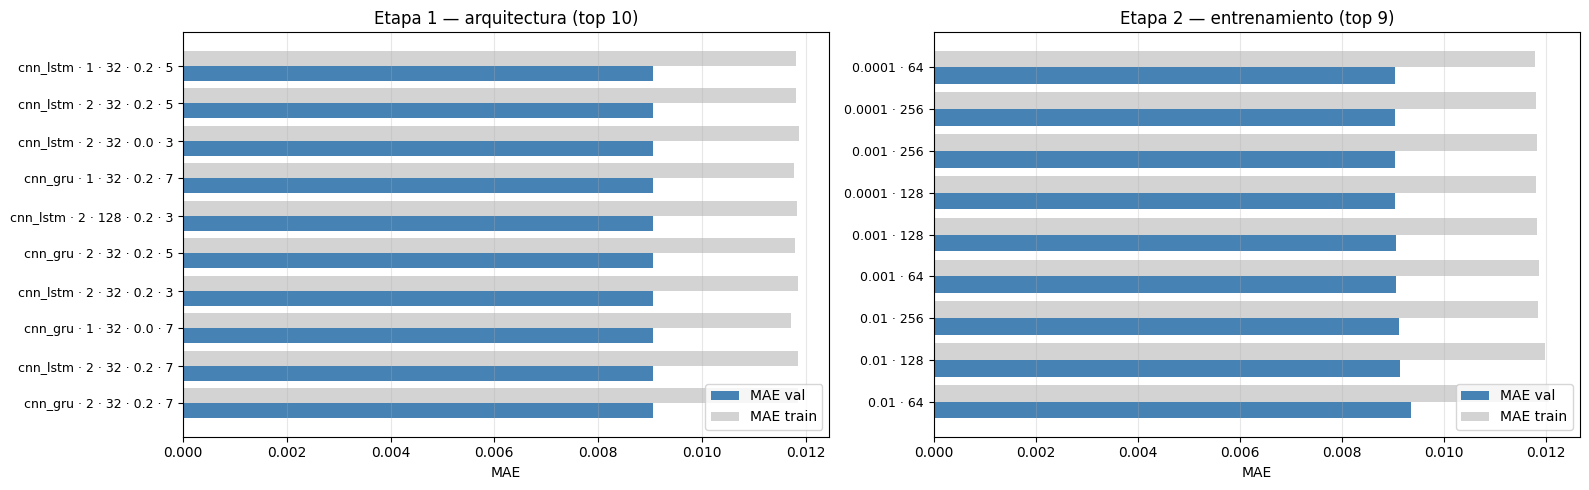

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

def plot_top(ax, df, label_cols, title, top=10):
    top_df = df.head(top).iloc[::-1]
    labels = top_df[label_cols].astype(str).agg(" · ".join, axis=1)
    ypos = np.arange(len(top_df))
    ax.barh(ypos - 0.2, top_df["MAE_val"],   height=0.4, label="MAE val",   color="steelblue")
    ax.barh(ypos + 0.2, top_df["MAE_train"], height=0.4, label="MAE train", color="lightgray")
    ax.set_yticks(ypos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("MAE")
    ax.set_title(title)
    ax.legend(loc="lower right")
    ax.grid(True, axis="x", alpha=0.3)

# Para Etapa 1 incluimos kernel_size en la etiqueta de las CNN (0 = no aplica)
arch_label_cols = ["arch", "n_layers", "units", "dropout", "kernel_size"]
plot_top(axes[0], results_arch_df,  arch_label_cols,
         "Etapa 1 — arquitectura (top 10)")
plot_top(axes[1], results_train_df, ["learning_rate", "batch_size"],
         "Etapa 2 — entrenamiento (top 9)")

plt.tight_layout()
plt.show()